# Exercise 4.10 - part 1.2 (Q&A: 5 - 10)

## Table of content

1.1 Importing Libraries

1.2 Importing Data Sets

5. Customer Profiling
6. Visualization to show the distribution of profiles
7. Statistical analysis on usage frequency and expenditure
8. Comparing customer profiles with regions and departments.
9. Charts to illustrate results from point 8
10. Exporting final data set

## 1.1. Importing Libraries

In [3]:
# Importing analysis and visual libraries

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

## 1.2. Importing Data Set

In [6]:
# Creating path

In [7]:
path=r'/Users/konstant/Documents/Achievement 4. Instacart Basket Analysis'

In [8]:
# Importing most up-to-date data set from part 1.1: 'final_merge_non_pii_part1.pkl

In [9]:
df_final_merge_non_pii= pd.read_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'final_merge_non_pii_part1.pkl'))

# 5. Customer Profiling

In [11]:
# Create a profiling variable based on age, income, certain goods in the “department_id” column, number of dependents, hour of purchase and day of the week.


In [12]:
# First create a data dictionary and importing the departments file

In [13]:
departments = pd.read_csv(os.path.join(path, '02 Data', 'Original Data', 'departments.csv'), index_col = False)

In [14]:
data_dict=departments.to_dict('index')

In [15]:
data_dict

{0: {'department_id': 'department',
  '1': 'frozen',
  '2': 'other',
  '3': 'bakery',
  '4': 'produce',
  '5': 'alcohol',
  '6': 'international',
  '7': 'beverages',
  '8': 'pets',
  '9': 'dry goods pasta',
  '10': 'bulk',
  '11': 'personal care',
  '12': 'meat seafood',
  '13': 'pantry',
  '14': 'breakfast',
  '15': 'canned goods',
  '16': 'dairy eggs',
  '17': 'household',
  '18': 'babies',
  '19': 'snacks',
  '20': 'deli',
  '21': 'missing'}}

In [16]:
# Checking the column headers of the data frame. 

In [17]:
df_final_merge_non_pii.columns.tolist()


['product_id',
 'product_name',
 'aisle_id',
 'department_id',
 'prices',
 'order_id',
 'user_id',
 'order_number',
 'orders_day_of_week',
 'hour_of_purchase',
 'days_since_prior_order',
 'add_to_cart_order',
 'reordered',
 'price_range_loc',
 'busiest_days',
 'busiest_period_of_day',
 'max_order',
 'loyalty_flag',
 'max_spend',
 'spending_flag',
 'days_since_last_order_median',
 'order_frequency_flag',
 'gender',
 'state',
 'age',
 'date_joined',
 'num_of_dependants',
 'fam_status',
 'income',
 '_merge',
 'region',
 'exclusion_flag']

In [18]:
# checking income brackets with scatterplot

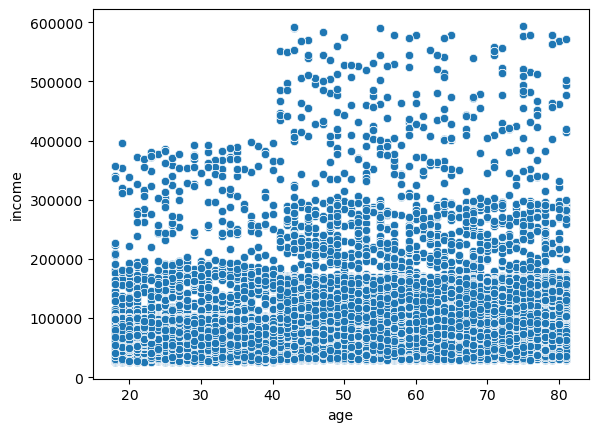

In [19]:
scat_age_income=sns.scatterplot(x = 'age', y = 'income',data = df_final_merge_non_pii)

In [20]:
# Defining customer profile rules

## Customer Profile Rules
### Young & Social
Age 18–30
Income ≤ 400,000
Dependents = 0
Departments: snacks, beverages, bakery, alcohol

### Busy Parent
Age 25–45
Dependents ≥ 1
Income 25,000–400,000
Departments: babies, breakfast, dairy eggs, pantry

### Affluent Foodie
Income > 200,000
Departments: meat seafood, international, bulk, alcohol

### Home Essentials Shopper
Any age
Departments: household, personal care, canned goods, dry goods
Steady shopping pattern, anytime, any day

### Budget Conscious
Income ≤ 200,000
Dependents ≥ 2
Departments: canned goods, frozen, produce, bakery

### Senior Shopper
Age ≥ 60
Income ≤ 600,000
Departments: frozen, canned goods, personal care
Shops mornings (6–11), any day

### Weekend Stock-Up
Any age
Shops weekends (day 5–6)
Orders early (8–12)
Departments: pantry, produce, dairy, dry goods

### Pet Owner
Any age/income
Department: pets

### Bulk Buyer
Income ≥ 100,000
Departments: bulk, household, meat seafood
Shops off-peak hours (10–15), any day

### Other
Anything that doesn’t match above

In [22]:
# Now defining the conditions and the command 

In [23]:
def profile_customer(row):
    age = row['age']
    income = row['income']
    deps = row['num_of_dependants']
    dept = row['department_id']
    day = row['orders_day_of_week']
    hour = row['hour_of_purchase']
    
    if (18 <= age <= 30 and income <= 400000 and deps == 0 and 
        dept in [19, 7, 3, 5]):
        return 'Young & Social'
    
    elif (25 <= age <= 45 and deps >= 1 and 25000 <= income <= 400000 and 
          dept in [18, 14, 16, 13]):
        return 'New Parent'
    
    elif (income > 200000 and dept in [12, 6, 10, 5]):
        return 'Affluent Foodie'
    
    elif dept in [17, 11, 15, 9]:
        return 'Home Essentials Shopper'
    
    elif (income <= 200000 and deps >= 2 and dept in [15, 1, 4, 3]):
        return 'Budget Conscious'

    elif (age >= 60 and income <= 600000 and 
          dept in [1, 15, 11]):
        return 'Senior Shopper'
    
    elif (day in [5, 6] and 8 <= hour <= 12 and dept in [13, 4, 16, 9]):
        return 'Weekend Stock-Up'
    
    elif dept == 8:
        return 'Pet Owner'
    
    elif income <= 400000 and dept in [10, 17, 12] :
        return 'Bulk Buyer'
    
    else:
        return 'Other'

In [24]:
# Applying the function

In [25]:
df_final_merge_non_pii['customer_profile'] = df_final_merge_non_pii.apply(profile_customer, axis=1)

In [26]:
# Checking the results

In [27]:
df_final_merge_non_pii['customer_profile'].value_counts(dropna=False)

customer_profile
Other                      17399715
Budget Conscious            6128033
Home Essentials Shopper     2958373
New Parent                  1975395
Weekend Stock-Up             993854
Bulk Buyer                   702046
Senior Shopper               364610
Young & Social               335197
Pet Owner                     93060
Affluent Foodie               14281
Name: count, dtype: int64

# 6. Visualization to show the distribution of profiles

In [29]:
# Visualizing the distribution of profiles through a bar chart. 

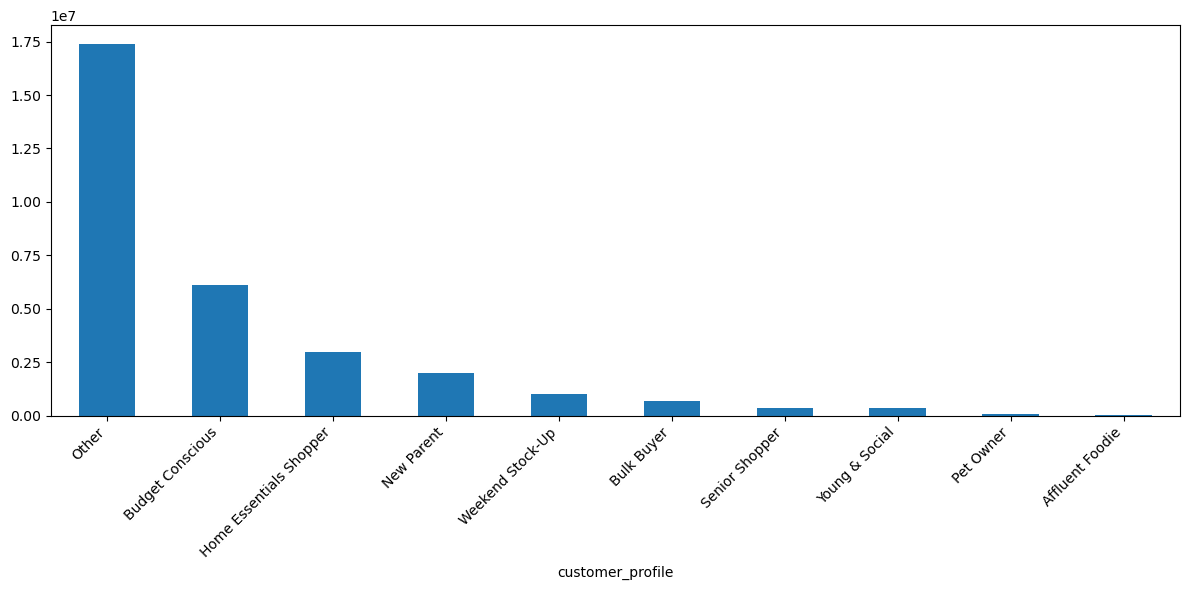

In [93]:
plt.figure(figsize=(12, 6))
bar_customer_profile=df_final_merge_non_pii['customer_profile'].value_counts().plot.bar()
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()

In [95]:
# Exporting the bar chart as a png file.

In [97]:
bar_customer_profile.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_customer_profile.png'))

# 7 Statistical analysis on usage frequency and expenditure

In [34]:
# Calculating the statistical summary on the variables 'max_spend' and 'max_order' for the various customer profiles. 

In [35]:
df_final_merge_non_pii.groupby('customer_profile')[['max_spend', 'max_order']].max()

,max_spend,max_order
customer_profile,,
Affluent Foodie,99999.0,99
Budget Conscious,99999.0,99
Bulk Buyer,99999.0,99
Home Essentials Shopper,99999.0,99
New Parent,99999.0,99
Other,99999.0,99
Pet Owner,99999.0,99
Senior Shopper,99999.0,99
Weekend Stock-Up,99999.0,99


In [36]:
df_final_merge_non_pii.groupby('customer_profile')[['max_spend', 'max_order']].min()

,max_spend,max_order
customer_profile,,
Affluent Foodie,14900.0,5
Budget Conscious,1.4,5
Bulk Buyer,6.1,5
Home Essentials Shopper,1.0,5
New Parent,1.8,5
Other,1.1,5
Pet Owner,7.1,5
Senior Shopper,5.3,5
Weekend Stock-Up,1.3,5


In [37]:
df_final_merge_non_pii.groupby('customer_profile')[['max_spend', 'max_order']].mean()

,max_spend,max_order
customer_profile,,
Affluent Foodie,23701.290036,38.760941
Budget Conscious,198.839594,34.568531
Bulk Buyer,234.774740,32.806340
Home Essentials Shopper,544.707991,31.830284
New Parent,401.083325,35.195972
Other,463.610167,34.773644
Pet Owner,771.863289,30.903740
Senior Shopper,727.802151,31.755585
Weekend Stock-Up,425.331365,36.186495


# 8. Comparing customer profiles with regions and departments. 

In [39]:
# Creating a crosstab with the customer profiles, regions and departments. 

In [100]:
crosstab=pd.crosstab(
    [df_final_merge_non_pii['customer_profile'], df_final_merge_non_pii['region']], 
    df_final_merge_non_pii['department_id'])

In [102]:
crosstab.to_clipboard()

### The crosstab above compares the different customer profiles with regions and typical department items that they purchase. The relationship between the customer profile and deprtment_id is quite clear as this is one of the main conditions that the customer profiles are based on. By adding the regions into the comparison, we can easily see if there is a pattern in consumer behaviour which can be used to target that specific segment of the customer base.  

# 9. Charts to illustrate results from point 8.

In [43]:
# A heat map is a good way to display the frequncy of department_id purchases compared to the various customer profiles. 

In [44]:
# Also exporting the heat map as a png file in the same code line

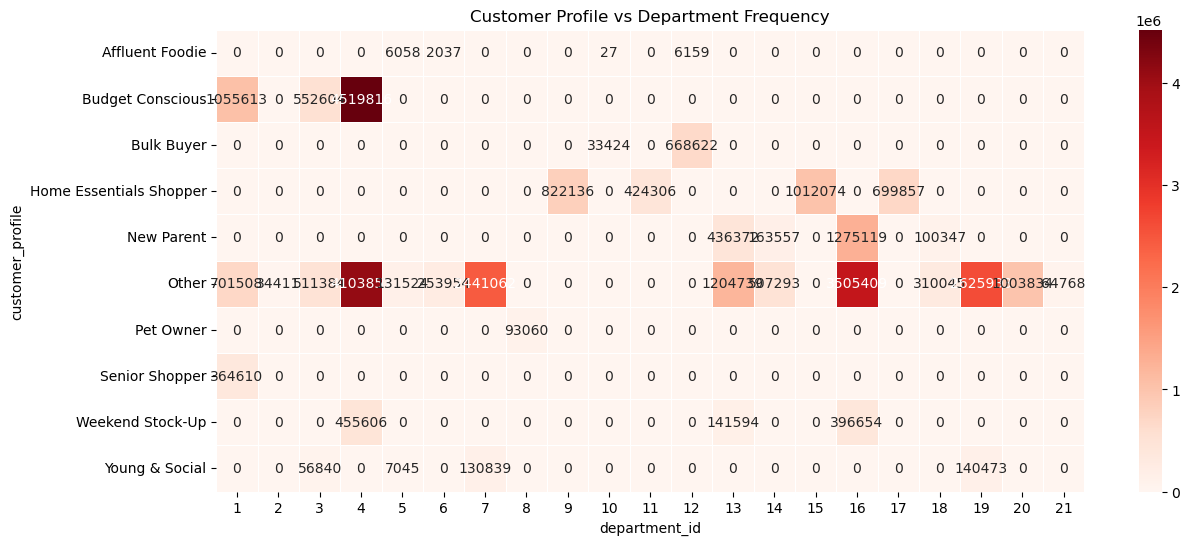

In [45]:
heat_customer_profile_vs_department = df_final_merge_non_pii.groupby(['customer_profile', 'department_id']).size().unstack().fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(heat_customer_profile_vs_department, cmap='Reds', linewidths=.5, annot=True, fmt='.0f')
plt.title("Customer Profile vs Department Frequency")

plt.savefig(os.path.join(path, '04 Analysis','Visualizations', 'heat_customer_profile_vs_department'), dpi=300, bbox_inches='tight')
plt.show()

In [46]:
# Duplicating the heat map above to display the frequncy of regions compared to the various customer profiles. 

In [47]:
# # Also exporting the heat map as a png file in the same code line

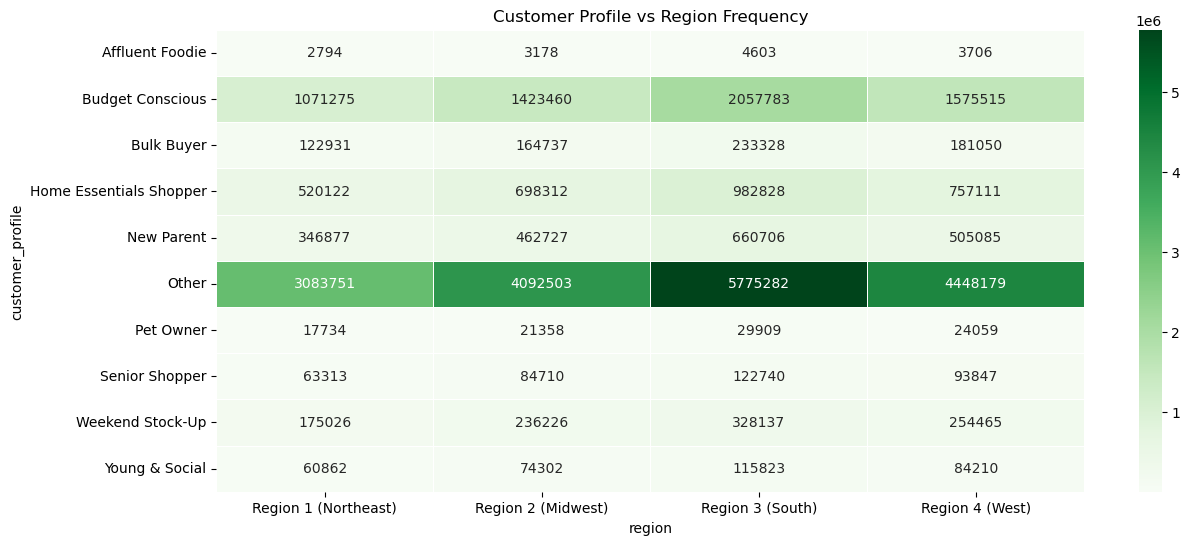

In [48]:
heat_customer_profile_vs_region = df_final_merge_non_pii.groupby(['customer_profile', 'region']).size().unstack().fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(heat_customer_profile_vs_region, cmap='Greens', linewidths=.5, annot=True, fmt='.0f')
plt.title("Customer Profile vs Region Frequency")

plt.savefig(os.path.join(path, '04 Analysis','Visualizations', 'heat_customer_profile_vs_region'), dpi=300, bbox_inches='tight')
plt.show()

# 10. Exporting final data set 

In [50]:
# Exporting final data set as a pickel file: 'final_master_data_set'

In [51]:
df_final_merge_non_pii.to_pickle(os.path.join(path, '02 Data','Prepared Data', 'final_master_data_set.pkl'))